# Task 1 of the Project

## Setup and Data Loading

Successfully loaded 50 image paths from 'example_json/input.json'.

Testing image load for: development_set/22f_png.rf.5f4dedb3e61ea2ced7d183a74035d313.jpg


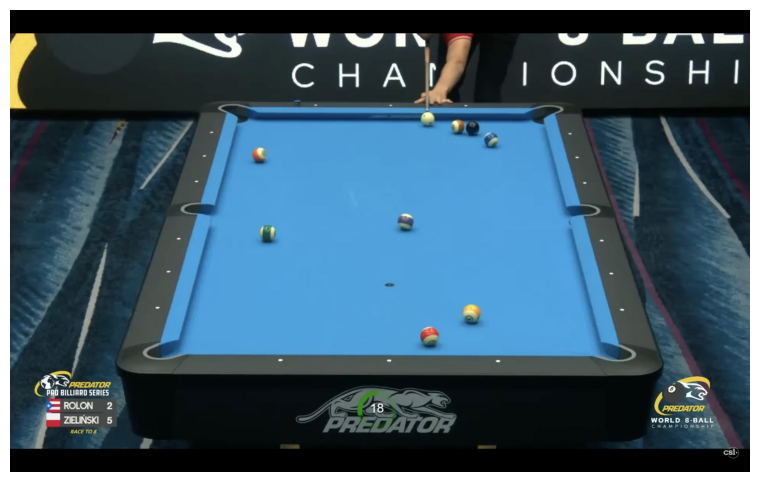

In [246]:
import json
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

INPUT_FILE = 'example_json/input.json'
OUTPUT_FILE = 'output.json'
TOP_VIEW_DIR = 'top_views'

os.makedirs(TOP_VIEW_DIR, exist_ok=True)

try:
    with open(INPUT_FILE, 'r') as f:
        input_data = json.load(f)
        
    image_paths = input_data.get("image_path", [])
    print(f"Successfully loaded {len(image_paths)} image paths from '{INPUT_FILE}'.")
    
    # Load and display the first image to verify everything is working
    if len(image_paths) > 0:
        first_image_path = 'development_set/22f_png.rf.5f4dedb3e61ea2ced7d183a74035d313.jpg'
        print(f"\nTesting image load for: {first_image_path}")
        
        img = cv2.imread(first_image_path)
        
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(10, 6))
            plt.imshow(img_rgb)
            plt.axis('off')
            plt.show()
        else:
            print(f"ERROR: Could not read the image at '{first_image_path}'.")

except FileNotFoundError:
    print(f"ERROR: The file '{INPUT_FILE}' was not found.")

## Top-View Generation

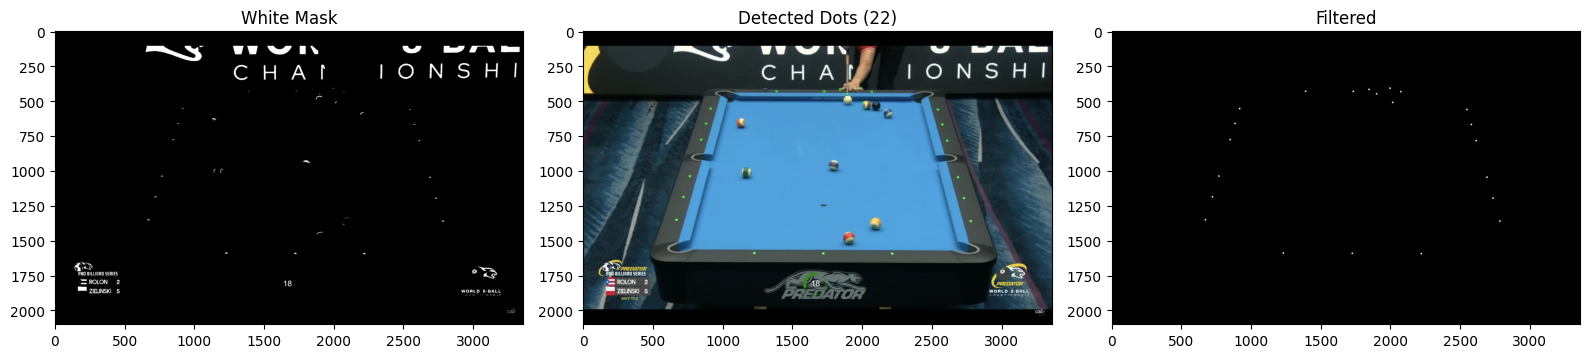

Edges order:
0: edge 0 | (985, 460) -> (683, 1580) | triplets=2
1: edge 1 | (683, 1580) -> (2760, 1588) | triplets=1
2: edge 2 | (2760, 1588) -> (2477, 471) | triplets=2
3: edge 3 | (2477, 471) -> (985, 460) | triplets=0
Chosen edge: 2 (2760, 1588) -> (2477, 471)
Ordered points [TL, TR, BR, BL]:
[[2477.  471.]
 [2760. 1588.]
 [ 683. 1580.]
 [ 985.  460.]]


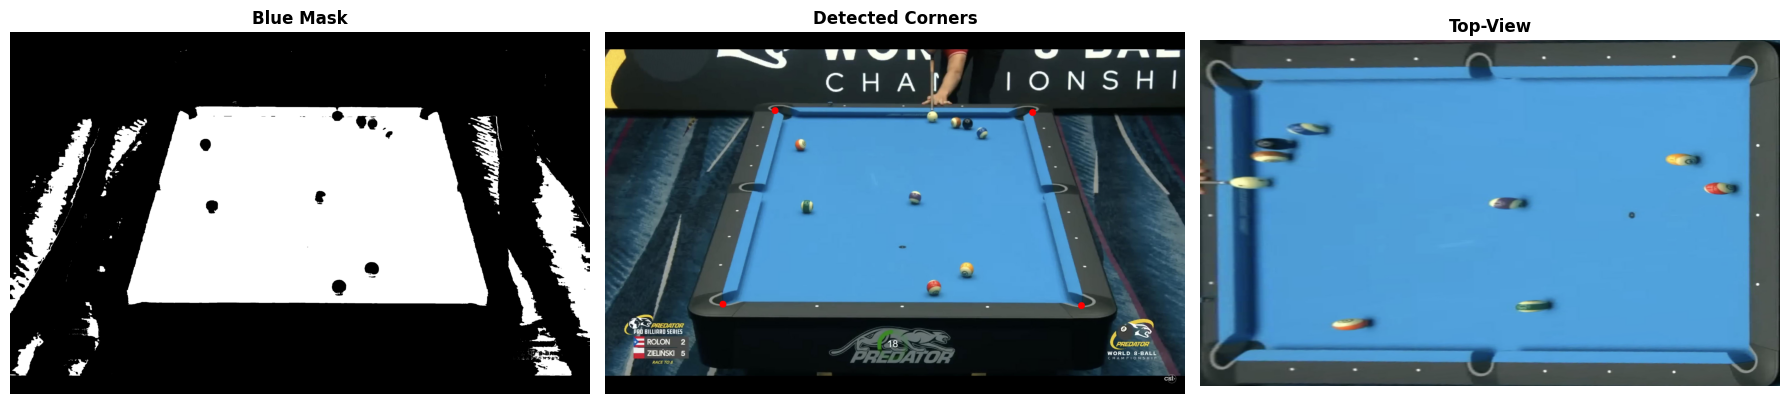

In [248]:
from itertools import combinations

def detect_white_dots(img_hsv, img_rgb, corners):
    def merge_close_dots(dots, dist_thresh):
        if not dots:
            return []

        pts = np.array([[x, y] for x, y, _ in dots], dtype=np.float32)
        areas = np.array([a for _, _, a in dots], dtype=np.float32)

        visited = np.zeros(len(dots), dtype=bool)
        merged = []

        for i in range(len(dots)):
            if visited[i]:
                continue

            stack = [i]
            cluster = []

            while stack:
                idx = stack.pop()
                if visited[idx]:
                    continue

                visited[idx] = True
                cluster.append(idx)

                for j in range(len(dots)):
                    if not visited[j]:
                        d = np.linalg.norm(pts[idx] - pts[j])
                        if d < dist_thresh:
                            stack.append(j)

            cluster_pts = pts[cluster]
            cluster_areas = areas[cluster]

            total_area = float(cluster_areas.sum())
            cx = int(np.average(cluster_pts[:, 0], weights=cluster_areas))
            cy = int(np.average(cluster_pts[:, 1], weights=cluster_areas))

            merged.append((cx, cy, total_area))

        return merged

    def point_to_segment_distance(pt, a, b):
        pt = np.array(pt, dtype=np.float32)
        a = np.array(a, dtype=np.float32)
        b = np.array(b, dtype=np.float32)

        ab = b - a
        denom = np.dot(ab, ab) + 1e-8
        t = np.dot(pt - a, ab) / denom
        t = np.clip(t, 0.0, 1.0)

        proj = a + t * ab
        return float(np.linalg.norm(pt - proj))

    def filter_dots_near_border(dots, corners, max_border_dist):
        corners = np.array(corners, dtype=np.float32).reshape(4, 2)

        edges = []
        for i in range(4):
            a = corners[i]
            b = corners[(i + 1) % 4]
            edges.append((a, b))

        filtered = []
        for x, y, area in dots:
            p = (x, y)
            min_dist = min(point_to_segment_distance(p, a, b) for a, b in edges)

            if min_dist <= max_border_dist:
                filtered.append((x, y, area))

        return filtered

    lower_white = np.array([0, 0, 180])
    upper_white = np.array([180, 50, 255])

    white_mask = cv2.inRange(img_hsv, lower_white, upper_white)
    contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    min_area = 1
    max_area = 120

    raw_dots = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            M = cv2.moments(cnt)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                raw_dots.append((cx, cy, area))

    dots = merge_close_dots(raw_dots, dist_thresh=40)
    dots = filter_dots_near_border(dots, corners, max_border_dist=100)

    img_debug = img_rgb.copy()
    for cx, cy, area in dots:
        cv2.circle(img_debug, (cx, cy), 8, (0, 255, 0), 2)

    filtered_mask = np.zeros_like(white_mask)
    for cx, cy, area in dots:
        cv2.circle(filtered_mask, (cx, cy), 6, 255, -1)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    ax[0].imshow(white_mask, cmap='gray')
    ax[0].set_title("White Mask")

    ax[1].imshow(img_debug)
    ax[1].set_title(f"Detected Dots ({len(dots)})")

    ax[2].imshow(filtered_mask, cmap='gray')
    ax[2].set_title("Filtered")

    plt.tight_layout()
    plt.show()

    return dots

def find_side_triplets(dots, src_pts, line_tol, dist_tol, debug=False):
    pts = np.array([[x, y] for x, y, _ in dots], dtype=np.float32)
    corners = np.array(src_pts, dtype=np.float32).reshape(4, 2)

    def point_to_segment_distance_and_t(p, a, b):
        ab = b - a
        denom = np.dot(ab, ab) + 1e-8
        t = np.dot(p - a, ab) / denom
        t_clip = np.clip(t, 0.0, 1.0)
        proj = a + t_clip * ab
        dist = np.linalg.norm(p - proj)
        return float(dist), float(t)

    def triplet_score(p1, p2, p3, return_metrics=False):
        fit = cv2.fitLine(
            np.array([p1, p2, p3], dtype=np.float32),
            cv2.DIST_L2,
            0,
            0.01,
            0.01
        )
        vx, vy, x0, y0 = [float(v.item()) for v in fit]

        residuals = [abs(vx * (p[1] - y0) - vy * (p[0] - x0)) for p in [p1, p2, p3]]
        line_err = float(np.mean(residuals))

        d12 = float(np.linalg.norm(np.array(p1) - np.array(p2)))
        d23 = float(np.linalg.norm(np.array(p2) - np.array(p3)))

        if min(d12, d23) < 1e-8:
            if return_metrics:
                return None, line_err, None, d12, d23
            return None

        rel_err = abs(d12 - d23) / max(d12, d23)

        if line_err > line_tol or rel_err > dist_tol:
            if return_metrics:
                return None, line_err, rel_err, d12, d23
            return None

        score = line_err + 50.0 * rel_err

        if return_metrics:
            return score, line_err, rel_err, d12, d23
        return score

    edges = []
    for i in range(4):
        a = corners[i]
        b = corners[(i + 1) % 4]
        edges.append({
            "idx": i,
            "a": tuple(map(int, a)),
            "b": tuple(map(int, b)),
            "assigned_pts": [],
            "ordered_points": [],
            "triplets": []
        })

    if debug:
        print("\n=== POINT ASSIGNMENT ===")

    for p in pts:
        best_edge = None
        best_dist = None
        best_t = None
        dists = []

        for i in range(4):
            a = corners[i]
            b = corners[(i + 1) % 4]
            d, t = point_to_segment_distance_and_t(p, a, b)
            dists.append((i, d, t))

            if best_dist is None or d < best_dist:
                best_dist = d
                best_t = t
                best_edge = i

        if debug:
            p_int = tuple(map(int, p))
            dists_str = " | ".join([f"e{i}: d={d:.1f}, t={t:.3f}" for i, d, t in dists])
            print(f"Point {p_int} -> {dists_str}")
            print(f"  assigned to edge {best_edge} (dist={best_dist:.2f}, t={best_t:.3f})")

        edges[best_edge]["assigned_pts"].append((best_t, tuple(map(int, p))))

    for e in edges:
        e["assigned_pts"].sort(key=lambda x: x[0])
        ordered = [p for _, p in e["assigned_pts"]]
        e["ordered_points"] = ordered

        if debug:
            print(f"\n=== EDGE {e['idx']} ===")
            print(f"Segment: {e['a']} -> {e['b']}")
            print(f"Ordered points ({len(ordered)}): {ordered}")

        candidates = []
        for i, j, k in combinations(range(len(ordered)), 3):
            if (j - i > 2) or (k - j > 2):
                if debug:
                    print(f"  comb ({i},{j},{k}) skipped by gap rule")
                continue

            p1, p2, p3 = ordered[i], ordered[j], ordered[k]
            score, line_err, rel_err, d12, d23 = triplet_score(
                p1, p2, p3, return_metrics=True
            )

            gap_penalty = 0.0
            if score is not None:
                gap_penalty = 20.0 * ((j - i - 1) + (k - j - 1))
                final_score = score + gap_penalty

            if debug:
                status = "PASS" if score is not None else "FAIL"
                print(
                    f"  comb ({i},{j},{k}): {p1}, {p2}, {p3} | "
                    f"d12={d12:.2f}, d23={d23:.2f}, "
                    f"line_err={line_err:.2f}, rel_err={rel_err if rel_err is not None else None}, "
                    f"gap_penalty={gap_penalty:.2f} -> {status}"
                )

            if score is not None:
                candidates.append({
                    "points": (p1, p2, p3),
                    "idxs": {i, j, k},
                    "score": final_score
                })

        candidates.sort(key=lambda x: x["score"])

        if debug:
            print("  valid candidates sorted by score:")
            for c in candidates:
                print(f"    {c['points']} | score={c['score']:.3f}")

        kept = []
        used = set()

        for c in candidates:
            if c["idxs"] & used:
                if debug:
                    print(f"    skipped overlap: {c['points']}")
                continue

            kept.append(c["points"])
            used |= c["idxs"]

            if debug:
                print(f"    kept: {c['points']}")

            if len(kept) == 2:
                break

        e["triplets"] = kept

        if debug:
            print(f"  final triplets: {e['triplets']}")

    large_edges = sorted(edges, key=lambda e: len(e["triplets"]), reverse=True)[:2]

    if debug:
        print("\n=== FINAL COUNTS ===")
        for e in edges:
            print(f"edge {e['idx']} -> {len(e['triplets'])} triplets")
        print("large_edges:", [e["idx"] for e in large_edges])

    return edges, large_edges

def choose_main_edge(edges, img_shape):
    def point_to_segment_distance(pt, a, b):
        pt = np.array(pt, dtype=np.float32)
        a = np.array(a, dtype=np.float32)
        b = np.array(b, dtype=np.float32)

        ab = b - a
        denom = np.dot(ab, ab) + 1e-8
        t = np.dot(pt - a, ab) / denom
        t = np.clip(t, 0.0, 1.0)

        proj = a + t * ab
        return float(np.linalg.norm(pt - proj))

    h, w = img_shape[:2]
    top_right = np.array([w - 1, 0], dtype=np.float32)

    candidates = [e for e in edges if len(e["triplets"]) == 2]

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) >= 2:
        ranked = sorted(
            candidates,
            key=lambda e: (
                point_to_segment_distance(top_right, e["a"], e["b"]),
                (e["a"][1] + e["b"][1]) / 2.0,
                -((e["a"][0] + e["b"][0]) / 2.0)
            )
        )
        return ranked[0]

    return max(edges, key=lambda e: len(e["triplets"]))

def order_points_from_main_edge(edges, main_edge):
    n = len(edges)
    main_idx = main_edge["idx"]

    prev_idx = (main_idx - 1) % n
    next_idx = (main_idx + 1) % n

    top_left = tuple(main_edge["b"])
    top_right = tuple(main_edge["a"])
    bottom_right = tuple(edges[prev_idx]["a"])
    bottom_left = tuple(edges[next_idx]["b"])

    ordered = np.array(
        [top_left, top_right, bottom_right, bottom_left],
        dtype=np.float32
    )

    return ordered

def crop_top_view(top_view, BORDER, WIDTH, HEIGHT, target_hls, l_tol, s_tol, min_ratio, padding):
    def largest_contiguous_block(idxs):
        if len(idxs) == 0:
            return None

        start = idxs[0]
        prev = idxs[0]
        best = (start, prev)

        for x in idxs[1:]:
            if x == prev + 1:
                prev = x
            else:
                if (prev - start) > (best[1] - best[0]):
                    best = (start, prev)
                start = prev = x

        if (prev - start) > (best[1] - best[0]):
            best = (start, prev)

        return best

    h, w = top_view.shape[:2]

    hls = cv2.cvtColor(top_view, cv2.COLOR_RGB2HLS)
    H, L, S = cv2.split(hls)

    target_h, target_l, target_s = target_hls

    grey_mask = (
        (np.abs(L.astype(np.int16) - target_l) <= l_tol) &
        (S.astype(np.int16) <= target_s + s_tol)
    ).astype(np.uint8) * 255

    top_zone = grey_mask[0:BORDER, BORDER:BORDER + WIDTH]
    top_ratios = top_zone.mean(axis=1) / 255.0
    top_valid = np.where(top_ratios >= min_ratio)[0]
    top_block = largest_contiguous_block(top_valid)

    if top_block is None:
        cut_top = 0
    else:
        cut_top = max(0, top_block[0] - padding)

    start_bottom = BORDER + HEIGHT
    bottom_zone = grey_mask[start_bottom:h, BORDER:BORDER + WIDTH]
    bottom_ratios = bottom_zone.mean(axis=1) / 255.0
    bottom_valid = np.where(bottom_ratios >= min_ratio)[0]
    bottom_block = largest_contiguous_block(bottom_valid)

    if bottom_block is None:
        cut_bottom = h
    else:
        cut_bottom = min(h, start_bottom + bottom_block[1] + 1 + padding)

    left_zone = grey_mask[BORDER:BORDER + HEIGHT, 0:BORDER]
    left_ratios = left_zone.mean(axis=0) / 255.0
    left_valid = np.where(left_ratios >= min_ratio)[0]
    left_block = largest_contiguous_block(left_valid)

    if left_block is None:
        cut_left = 0
    else:
        cut_left = max(0, left_block[0] - padding)

    start_right = BORDER + WIDTH
    right_zone = grey_mask[BORDER:BORDER + HEIGHT, start_right:w]
    right_ratios = right_zone.mean(axis=0) / 255.0
    right_valid = np.where(right_ratios >= min_ratio)[0]
    right_block = largest_contiguous_block(right_valid)

    if right_block is None:
        cut_right = w
    else:
        cut_right = min(w, start_right + right_block[1] + 1 + padding)

    cropped = top_view[cut_top:cut_bottom, cut_left:cut_right]

    return cropped, grey_mask

# Convert to HSV color space
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Define the color range for the blue pool table cloth
lower_blue = np.array([90, 80, 80])
upper_blue = np.array([120, 255, 255])

# Create a mask that only keeps the blue pixels
mask = cv2.inRange(hsv, lower_blue, upper_blue)

# Find contours on the mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Assume the largest contour is the pool table
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Compute the perimeter of the contour
    peri = cv2.arcLength(largest_contour, True)

    # Reduce the contour vertices to a quadrilateral
    corners = cv2.approxPolyDP(largest_contour, 0.02 * peri, True)
    
    if len(corners) == 4:
        src_pts = corners.reshape(4, 2)

        dots = detect_white_dots(hsv, img_rgb, src_pts)

        edges, large_edges = find_side_triplets(dots, src_pts, line_tol=8, dist_tol=0.20, debug=False)

        main_edge = choose_main_edge(edges, img_rgb.shape)

        print("Edges order:")
        for pos, e in enumerate(edges):
            print(f"{pos}: edge {e['idx']} | {e['a']} -> {e['b']} | triplets={len(e['triplets'])}")
        print("Chosen edge:", main_edge["idx"], main_edge["a"], "->", main_edge["b"])

        ordered_pts = order_points_from_main_edge(edges, main_edge)
        print("Ordered points [TL, TR, BR, BL]:")
        print(ordered_pts)

        # Draw the points on a copy of the original image to visualize
        img_with_corners = img_rgb.copy()
        for i, pt in enumerate(ordered_pts):
            cv2.circle(img_with_corners, (int(pt[0]), int(pt[1])), 20, (255, 0, 0), -1)

        # ordered_pts = [TL, TR, BR, BL]
        tl, tr, br, bl = ordered_pts

        side_a = max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl))
        side_b = max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr))

        WIDTH = int(max(side_a, side_b))
        HEIGHT = int(min(side_a, side_b))

        BORDER = 200
        
        TOTAL_WIDTH = WIDTH + (2 * BORDER)
        TOTAL_HEIGHT = HEIGHT + (2 * BORDER)

        # X = Column | Y = Row
        dst_pts = np.array([
            [BORDER, BORDER], # TL
            [BORDER + WIDTH - 1, BORDER], # TR
            [BORDER + WIDTH - 1, BORDER + HEIGHT - 1], # BR
            [BORDER, BORDER + HEIGHT - 1] # BL
        ], dtype=np.float32)

        matrix = cv2.getPerspectiveTransform(ordered_pts.astype(np.float32), dst_pts)

        top_view = cv2.warpPerspective(img_rgb, matrix, (TOTAL_WIDTH, TOTAL_HEIGHT))

        border_top_view, grey_mask = crop_top_view(top_view, BORDER, WIDTH, HEIGHT, target_hls=(55, 87, 8), l_tol=35, s_tol=28, min_ratio=0.45, padding=4)

        fig, ax = plt.subplots(1, 3, figsize=(18, 6))

        ax[0].imshow(mask, cmap='gray')
        ax[0].set_title("Blue Mask", fontweight='bold')
        ax[0].axis('off')

        ax[1].imshow(img_with_corners)
        ax[1].set_title("Detected Corners", fontweight='bold')
        ax[1].axis('off')

        ax[2].imshow(border_top_view)
        ax[2].set_title("Top-View", fontweight='bold')
        ax[2].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f"ERROR: Found a contour, but it has {len(corners)} points instead of 4.")
else:
    print("ERROR: Could not find any blue areas.")